# 02 - Missing Values & Duplicate Audit


## Setup


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_PATH = Path('../../data/raw data/DataCoSupplyChainDataset.csv')  

try:
    df = pd.read_csv(DATA_PATH, encoding='utf-8')
except UnicodeDecodeError:
    print("UTF-8 failed, falling back to ISO-8859-1")
    df = pd.read_csv(DATA_PATH, encoding='ISO-8859-1')

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


UTF-8 failed, falling back to ISO-8859-1
Shape: 180,519 rows x 53 columns


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [7]:
missing_summary = pd.DataFrame({
    'column': df.columns,
    'n_missing': df.isnull().sum().values,
    'pct_missing': (df.isnull().sum().values / len(df) * 100).round(2),
})
missing_summary = missing_summary[missing_summary['n_missing'] > 0].sort_values('pct_missing', ascending=False)
missing_summary


,column,n_missing,pct_missing
46,Product Description,180519,100.00
43,Order Zipcode,155679,86.24
19,Customer Zipcode,3,0.00
14,Customer Lname,8,0.00


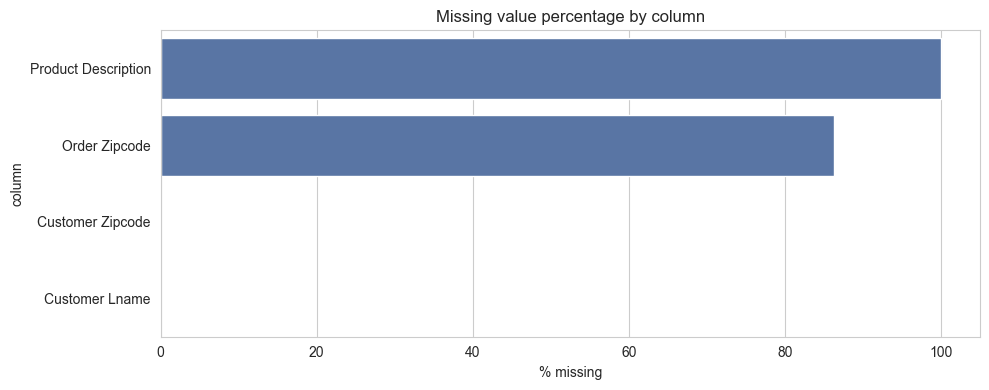

In [8]:
plt.figure(figsize=(10, max(4, len(missing_summary) * 0.3)))
sns.barplot(data=missing_summary, y='column', x='pct_missing', color='#4C72B0')
plt.xlabel('% missing')
plt.title('Missing value percentage by column')
plt.tight_layout()
plt.show()


In [9]:
n_exact_duplicates = df.duplicated().sum()
print(f"Exact duplicate rows: {n_exact_duplicates}")

if 'Order Id' in df.columns:
    n_duplicate_order_ids = df['Order Id'].duplicated().sum()
    print(f"Duplicate Order Ids: {n_duplicate_order_ids} (expected > 0 if data is order-line level)")


Exact duplicate rows: 0
Duplicate Order Ids: 114767 (expected > 0 if data is order-line level)


**What we found:**

- **Only 4 columns have any missing values at all** - this dataset is otherwise remarkably clean, which matters for Stage 3: we don't need a broad imputation strategy, just targeted handling for these four.

| Column | % missing | Systemic or random? | Implication |
|---|---|---|---|
| `Product Description` | 100.00% | **Systemic** - every single row is missing. This isn't a data quality issue to "fix," the column simply carries no information in this dataset. | **Drop entirely** in Stage 3. No imputation makes sense for a column with zero non-null values. |
| `Order Zipcode` | 86.24% | **Likely systemic**, not random - almost certainly tied to which country an order shipped to (zip codes don't apply the same way outside a few countries). Needs a quick check: `df.groupby('Order Country')['Order Zipcode'].apply(lambda x: x.notna().mean())` to confirm before Stage 3. | If confirmed systemic: either drop the column, or keep it only as a derived binary flag (`zipcode_available`) rather than trying to impute an address-specific number — imputing a fake zipcode would be meaningless. |
| `Customer Lname` | 8 rows (0.00%) | Negligible - likely just a handful of genuinely incomplete records, not a pattern. | Safe to drop these 8 rows or fill with `"Unknown"` - doesn't matter which, the volume is too small to affect anything. |
| `Customer Zipcode` | 3 rows (0.00%) | Same as above - negligible, no pattern worth investigating. | Drop or trivially impute; not worth further analysis. |

- **Zero exact duplicate rows.** No two rows in the entire dataset are 100% identical - this is a genuinely clean signal; we don't need any general de duplication step in Stage 3.
- **114,767 duplicate `Order Id` values - and this is expected, not a problem.** This directly confirms the order line level finding from Notebook 01 (65,752 unique orders across 180,519 rows means most `Order Id`s legitimately repeat across their line items). This number isn't a data quality flag - it's just arithmetic confirmation of something we already knew and planned for (aggregation to order level in Stage 3).

**Bottom line for Stage 3:** the only real preprocessing decisions here are (1) drop `Product Description` outright, (2) verify then likely drop-or-flag `Order Zipcode`, and (3) trivially handle the ~11 negligible missing rows in the two Customer fields. No complex imputation strategy is needed for this dataset - log this as a decision ("minimal imputation needed; two columns dropped, two negligible missing columns handled trivially") in `DECISION_LOG.md` so it's clear this was a deliberate, checked conclusion and not something skipped.
